# 19 — Let's try cellpose and stardist on bees! (simple version)

- how do ops calls look?
- In real life we process many images with many models
- Sometimes all the looping code obfuscates the API

 So let's just do one bee image as simple as possible!

In [6]:
from skimage.io import imread
from tnia.plotting.plt_helper import imshow_multi2d, mask_overlay
from pathlib import Path

from skop.runner import Runner

from skop.ops.segment.cellpose3 import cellpose3
from skop.ops.segment.cellpose3 import PretrainedModel as Cellpose3Model
from skop.ops.segment.cellpose4 import cellpose4
from skop.ops.segment.cellpose4 import PretrainedModel as Cellpose4Model

from skop.ops.segment.stardist2d import stardist2d_he

image_name = 'comb_03.png'
image = imread(Path('data') / 'bees' / image_name)

print(image.shape)

overlays=[]
titles=[]


(343, 512, 3)


## Cellpose 3, StarDist, Cellpose SAM

- `cyto3`: Cellpose 3's generalist model
- `stardist2d_he`: StarDist's H&E model. Not for bees, just testing the wiring (we retrain later)
- `cpsam_v2`: Cellpose 4's second generation SAM model
- Cellpose 3 and 4: different versions of one package, can't share an environment
- StarDist: TensorFlow, its own environment too
- Ops let us compare them anyway

In [7]:
runner = Runner()

cp3_result = runner.run(cellpose3, image=image, model=Cellpose3Model.cyto3, diameter=50.0)

runner.release()

overlays.append(mask_overlay(image,cp3_result))
titles.append('cellpose3')


In [8]:
stardist_result = runner.run(stardist2d_he, image=image)

runner.release()

overlays.append(mask_overlay(image, stardist_result))
titles.append('stardist he')

## Run CP4 Samv2

If you don't have a GPU activated, this may be slow on the CPU.  Skip if you don't have a GPU. 

In [9]:

cp4samv2_result = runner.run(cellpose4, image=image, model=Cellpose4Model.cpsam_v2, diameter=50.0)

runner.release()

overlays.append(mask_overlay(image, cp4samv2_result))
titles.append('cellpose4 samv2')



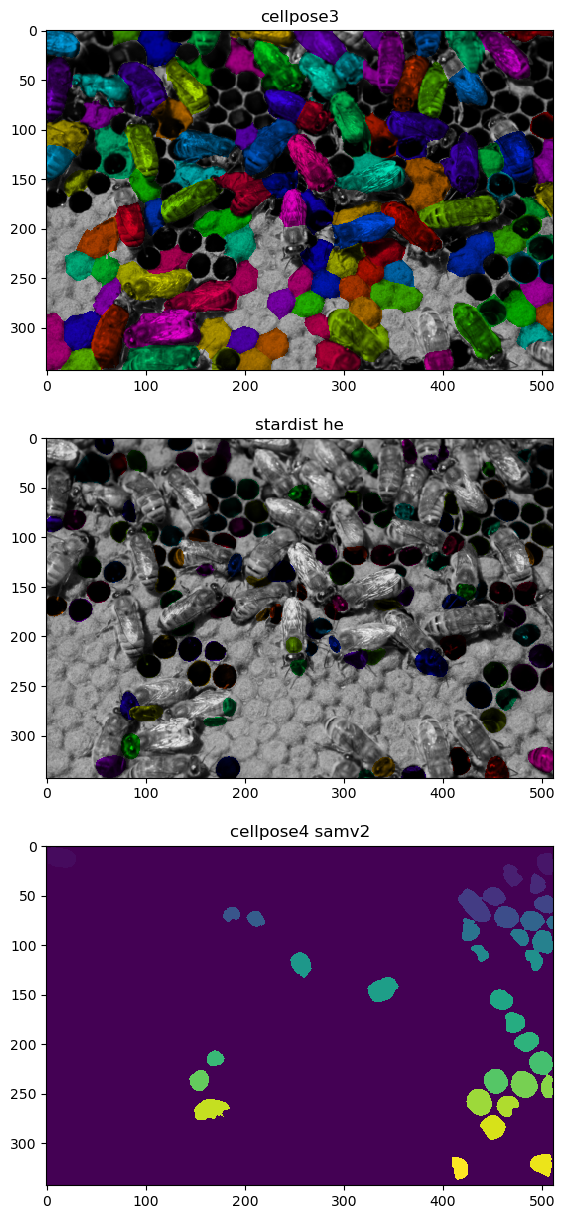

In [10]:
fig = imshow_multi2d(overlays, titles, len(overlays), 1, width=8, height=5*len(overlays))

Exercise 

Can you get better results by adjusting parameters?

Hint - to learn what parameters ops take just the usual 

```
help(op_name)
```